In [2]:
pip install ehtim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.0/445.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.9/131.9 kB 12.0 MB/s eta 0:00:00
  Created wheel for paramsurvey: filename=paramsurvey-0.4.21-py3-none-any.whl size=36647 sha256=13c5ac066c519fae719d71490d7c5eccb07f296e1198cbbb8acb5646c4d3fcea
  Stored in directory: /root/.cache/pip/wheels/8b/f8/99/8f3c76a241257caf637d7d481e5602c61a28076d436d63b495
  Created wheel for pandas-appender: filename=pandas_appender-0.9.9-py3-none-any.whl size

In [3]:
import numpy as np
import ehtim as eh
import ehtim.const_def as ehc

Welcome to eht-imaging! v 1.2.10 



In [4]:
#parameters for SgrA*
ra_hr = 17 + 45/60 + 40.0383/3600 #right ascension
dec_deg = -(29 + 28.069/3600) #declination
rf = 86e9 #observation freq in Hz
mjd = 58211 #modified julian date **THIS IS SET TO 2017 -- EDIT THIS

npix = 256 #number of pixals
fov_uas = 160.0 #field of view in microarcseconds
fov = fov_uas * ehc.RADPERUAS

#----------------------------------------
#Adjust this value to increase the total flux / flux of the accretion disk
#----------------------------------------
total_flux = 2.0
ring_diam_uas = 50.0 #approxiamte diameter of SgrA*
ring_diam_rad = ring_diam_uas * ehc.RADPERUAS

In [5]:
#------------------------------------------
#Adjust these values to vary the timing
#----------------------------------------
tstart_hr = 0.0
tstop_hr = 10.0/60.0    #these time values are in hours -> for one full revolution of max spin, set at 0.5
cadence_s = 2.0         #how many seconds between each frame

times_hr = np.arange(tstart_hr, tstop_hr + cadence_s/3600.0, cadence_s/3600.0)
print('nframes =', len(times_hr))

nframes = 301


In [21]:
#-----------------------------------------
#Adjust this value to change the hotspot flux / size
#----------------------------------------
hotspot_flux = 0.3
hotspot_fwhm_uas = 10.0
hotspot_fwhm_rad = hotspot_fwhm_uas * ehc.RADPERUAS

#-----------------------------------------
#Adjust this value to change the period / rate of spin of the hotspot
#----------------------------------------
period_min = 4.0 #in minutes
omega = 2*np.pi / (period_min/60.0)

imlist = []
for t_hr in times_hr:
  phi = omega * t_hr
  index = 0

  r_ring = ring_diam_rad/2.0
  x_hot = r_ring * np.cos(phi) * 0.8
  y_hot = r_ring * np.sin(phi) * 0.8

  mod = eh.model.Model(ra_hr, dec_deg, rf=rf, source="SgrA", mjd=mjd) #creates the background

  mod = mod.add_circ_gauss(F0 = hotspot_flux, FWHM = hotspot_fwhm_rad, x0=x_hot, y0=y_hot) #creates the hotspot

  #creates the ring -- PLEASE REMOVE THE HASHTAG TO INPUT INTO THE MOVIE -- also please check flux
  #mod = mod.add_ring(F0 = total_flux - hotspot_flux, d = ring_diam_rad, x0 = 0.0, y0 = 0.0)

  #creates the accretion disk
  mod = mod.add_crescent(F0=total_flux - hotspot_flux, #flux
                       d=ring_diam_rad, #2.424068405547068e-10, #microarcseconds in radians
                        #-------------------------------------
                         #adjust the thickness of the ring
                         #----------------------------------------
                       fr=0.6, #thickness of the ring
                       fo=0.4, #thickness of the ring
                       ff=0.0, #brightness of the inner disk
                       phi=(phi+np.pi/2)*-1, #moving the hotspot
                       x0=0.0,
                       y0=0.0,
                       pol_frac=0.0,
                       pol_evpa=0.0,
                       cpol_frac=0.0)

  im = mod.make_image(fov, npix)

  im.time = float(t_hr)

  imlist.append(im)


In [24]:
print(imlist)

[<ehtim.image.Image object at 0x7cd09b752ff0>, <ehtim.image.Image object at 0x7cd0c8e02f90>, <ehtim.image.Image object at 0x7cd0c9191280>, <ehtim.image.Image object at 0x7cd0c1229b80>, <ehtim.image.Image object at 0x7cd0c88addc0>, <ehtim.image.Image object at 0x7cd0c13bcd10>, <ehtim.image.Image object at 0x7cd0c13971d0>, <ehtim.image.Image object at 0x7cd0c8d0b350>, <ehtim.image.Image object at 0x7cd0c1547200>, <ehtim.image.Image object at 0x7cd0c99e69f0>, <ehtim.image.Image object at 0x7cd0c154e4b0>, <ehtim.image.Image object at 0x7cd0c13bcc50>, <ehtim.image.Image object at 0x7cd0c88e9520>, <ehtim.image.Image object at 0x7cd0c8c818e0>, <ehtim.image.Image object at 0x7cd0c13be750>, <ehtim.image.Image object at 0x7cd0c1396bd0>, <ehtim.image.Image object at 0x7cd0c89cab40>, <ehtim.image.Image object at 0x7cd0c89cb8c0>, <ehtim.image.Image object at 0x7cd0c88e63c0>, <ehtim.image.Image object at 0x7cd0c8c0e390>, <ehtim.image.Image object at 0x7cd0d6bbfc50>, <ehtim.image.Image object at 0x7c

In [18]:
#-----------------------------------------
# change this value to obtain the degree of the image that you would like
# please note that depending on the number of frames and period set, it may not
# be completely accurate in degrees, will find the closest degree to the value
#-----------------------------------------
degree = 0

#obtaining the frames
frame_length = len(imlist)
period_timehr = period_min/60
#finding the number of frames to complete one period
frames_per_period = int(frame_length * period_timehr) / tstop_hr
#degrees between each frame
deg_per_frame = 360 / frames_per_period
#creating a list that contains the degrees for each frame in a period
degree_list = np.arange(0, 360.01, deg_per_frame)
#normalizing -- due to the fact that the movie starts at 270 degrees
frames_to_skip = int(90/deg_per_frame)
#finding index given the degree set
idx = (np.abs(degree_list - degree)).argmin()
real_idx = idx + frames_to_skip

#saving the image
imlist[real_idx].save_fits(f'Ground Truth {degree} degrees.fits')

In [22]:
#please only run this cell when you want ALL frames
for image in imlist:
  image.save_fits(f'{image}')

In [19]:
import ehtim.movie as movie

In [23]:
mov = movie.merge_im_list(imlist, interp="linear", bounds_error=False)

mov.export_mp4(
    out="sgrA_toy_ground_truth.mp4",
    fps = 20,
    dpi = 160,
    scale = 'lin',
    dynamic_range = 1000.0,
    cfun = "afmhot",
    label_time = True,
    verbose = True
)


Merging 301 frames from MJD 58211 0.00 hr to MJD 58211 0.17 hr
processing frame 0 of 301
processing frame 0 of 301
processing frame 1 of 301
processing frame 2 of 301
processing frame 3 of 301
processing frame 4 of 301
processing frame 5 of 301
processing frame 6 of 301
processing frame 7 of 301
processing frame 8 of 301
processing frame 9 of 301
processing frame 10 of 301
processing frame 11 of 301
processing frame 12 of 301
processing frame 13 of 301
processing frame 14 of 301
processing frame 15 of 301
processing frame 16 of 301
processing frame 17 of 301
processing frame 18 of 301
processing frame 19 of 301
processing frame 20 of 301
processing frame 21 of 301
processing frame 22 of 301
processing frame 23 of 301
processing frame 24 of 301
processing frame 25 of 301
processing frame 26 of 301
processing frame 27 of 301
processing frame 28 of 301
processing frame 29 of 301
processing frame 30 of 301
processing frame 31 of 301
processing frame 32 of 301
processing frame 33 of 301
pr

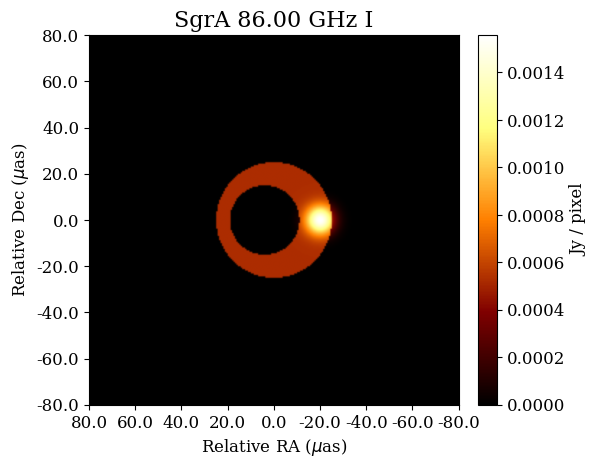

In [27]:
imlist[-1].display()